In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import altair as alt

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('music_streams.csv')
df['explicit'] = df['explicit'].astype(str)
print(df.shape)
df.head(3)

(1200, 21)


,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans


---
# Part 1 — Seaborn

## Histogram
### Distribution of monthly streams — right-skewed, most songs under 20M

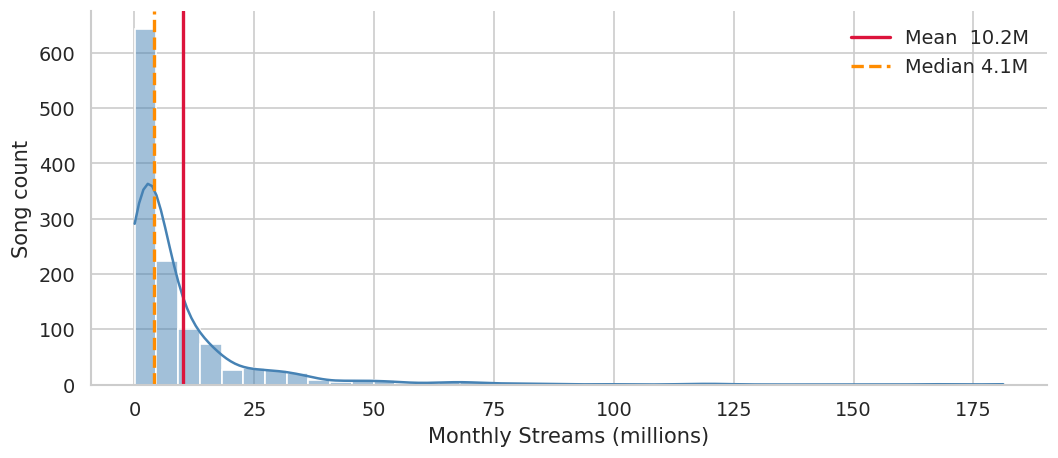

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))

sns.histplot(df[df.streams_millions < 200], x='streams_millions',
             bins=40, kde=True, ax=ax, color='steelblue')

ax.axvline(df.streams_millions.mean(),   color='crimson',    lw=2, label=f"Mean  {df.streams_millions.mean():.1f}M")
ax.axvline(df.streams_millions.median(), color='darkorange', lw=2, linestyle='--',
           label=f"Median {df.streams_millions.median():.1f}M")

ax.set_xlabel('Monthly Streams (millions)')
ax.set_ylabel('Song count')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## Box Plot
### Energy distribution by genre — Rock and Electronic dominate

/tmp/ipykernel_563/2885644088.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y='energy', order=order,


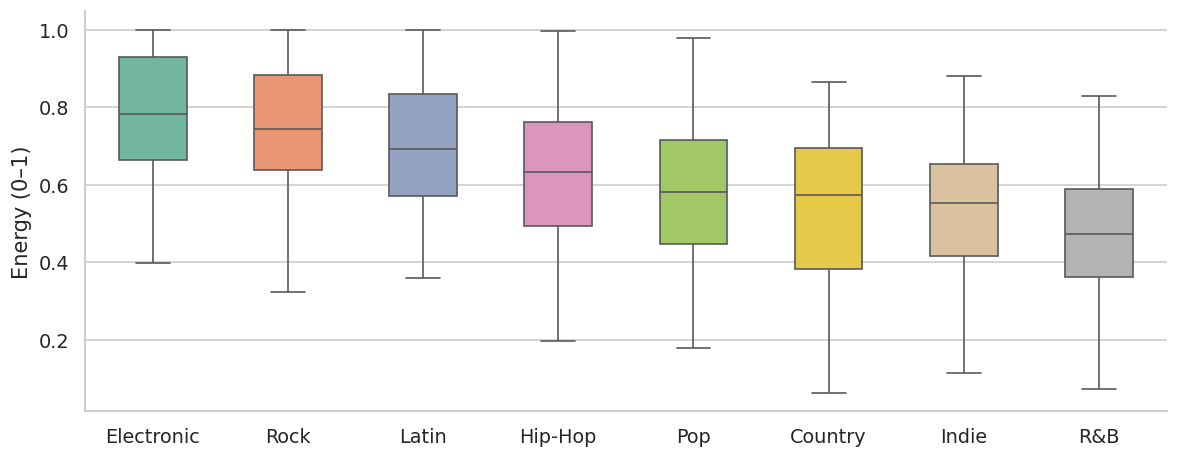

In [3]:
order = df.groupby('genre')['energy'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, x='genre', y='energy', order=order,
            palette='Set2', width=0.5, flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Energy (0–1)')
sns.despine()
plt.tight_layout()
plt.show()

## Scatter Plot
### Energy vs danceability — positively correlated across genres

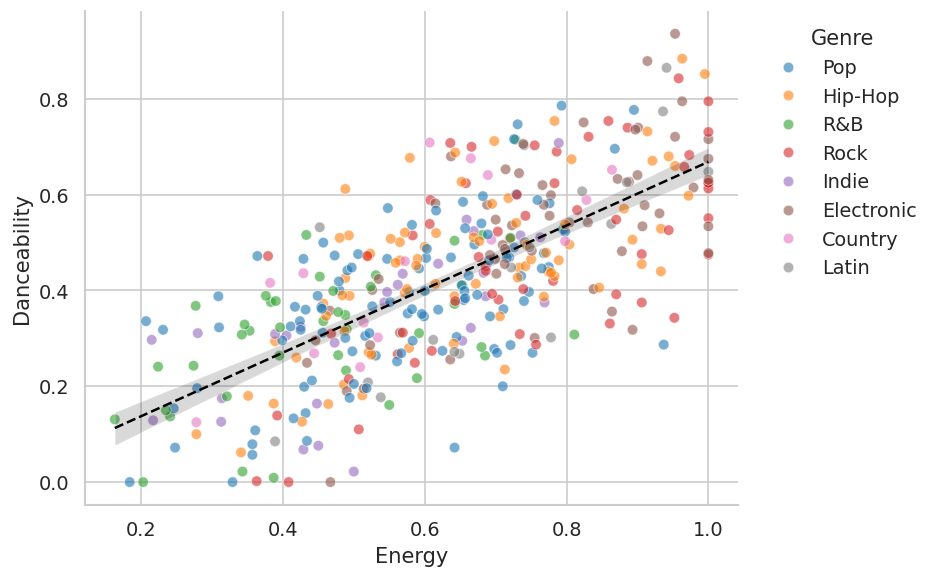

In [4]:
sample = df.sample(400, random_state=1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sample, x='energy', y='danceability',
                hue='genre', alpha=0.6, s=40, palette='tab10', ax=ax)
sns.regplot(data=sample, x='energy', y='danceability',
            scatter=False, color='black', line_kws={'lw': 1.5, 'linestyle': '--'}, ax=ax)
ax.legend(bbox_to_anchor=(1.02, 1), frameon=False, title='Genre')
ax.set_xlabel('Energy')
ax.set_ylabel('Danceability')
sns.despine()
plt.tight_layout()
plt.show()

## Bar Chart
### Median streams by genre — Pop and Hip-Hop lead

/tmp/ipykernel_563/1231507313.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=med, x='genre', y='streams_millions', palette='Set2', ax=ax)


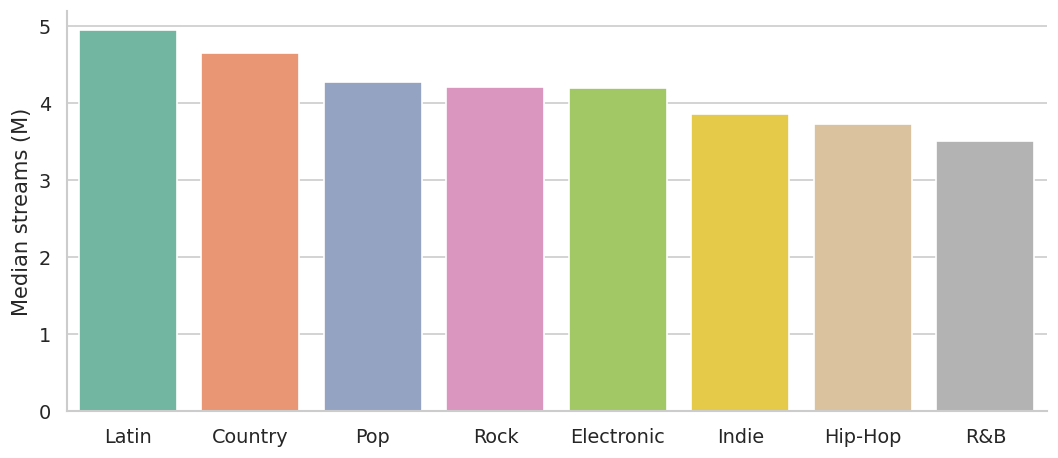

In [5]:
med = df.groupby('genre')['streams_millions'].median().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=med, x='genre', y='streams_millions', palette='Set2', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Median streams (M)')
sns.despine()
plt.tight_layout()
plt.show()

## Violin Plot
### Tempo distribution by genre — Electronic skews fast, Country and R&B slower

/tmp/ipykernel_563/2560014046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='genre', y='tempo_bpm', order=order,


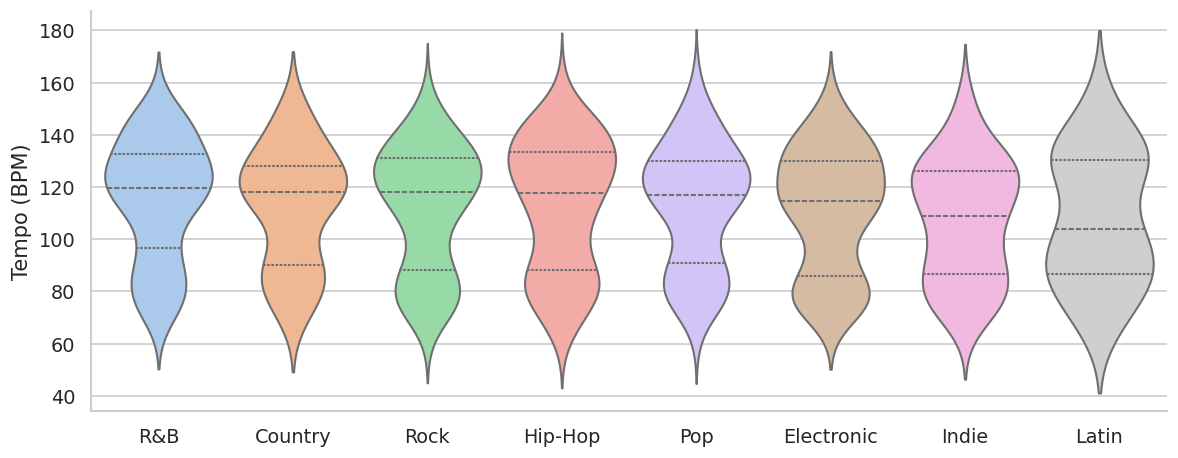

In [6]:
order = df.groupby('genre')['tempo_bpm'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 4))
sns.violinplot(data=df, x='genre', y='tempo_bpm', order=order,
               palette='pastel', inner='quartile', ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Tempo (BPM)')
sns.despine()
plt.tight_layout()
plt.show()

## Heatmap
### Correlation matrix of audio features — danceability and energy tightly linked

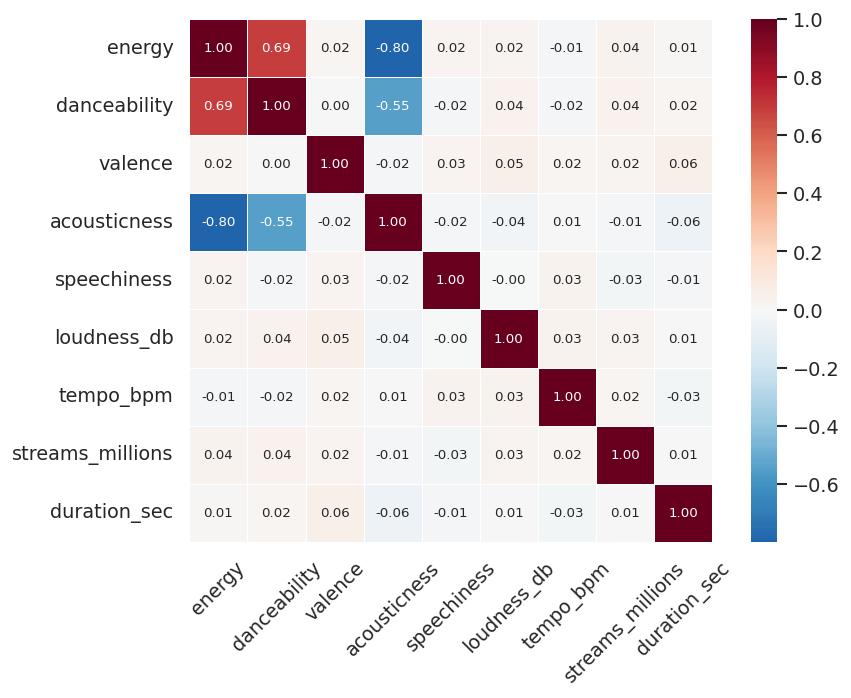

In [7]:
cols = ['energy','danceability','valence','acousticness','speechiness',
        'loudness_db','tempo_bpm','streams_millions','duration_sec']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, ax=ax,
            annot_kws={'size': 8})
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
# Part 2 — Matplotlib (Complex / Annotated)

## Annotated Scatter
### Streams vs playlist adds — outliers labeled, quadrants marked

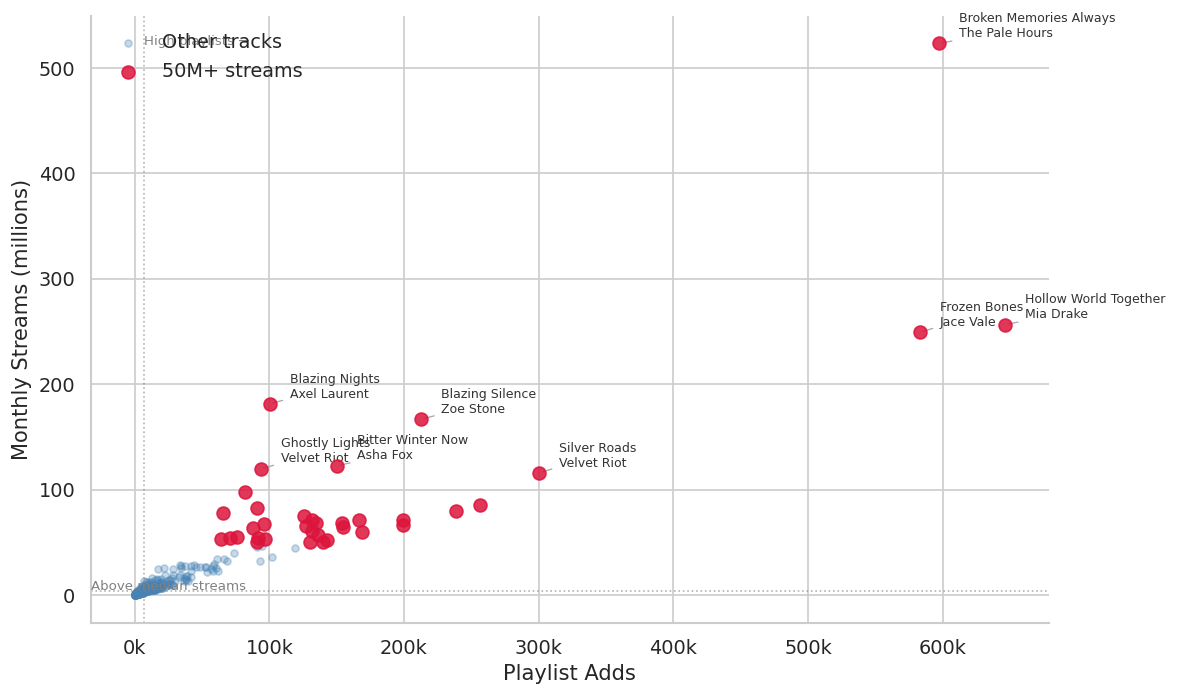

In [8]:
top = df[df.streams_millions > 50].copy()
rest = df[df.streams_millions <= 50].sample(300, random_state=7)

fig, ax = plt.subplots(figsize=(10, 6))

# Background scatter
ax.scatter(rest['playlist_adds'], rest['streams_millions'],
           alpha=0.3, s=18, color='steelblue', label='Other tracks')

# Top tracks
ax.scatter(top['playlist_adds'], top['streams_millions'],
           alpha=0.85, s=60, color='crimson', zorder=5, label='50M+ streams')

# Label top 8
top8 = top.nlargest(8, 'streams_millions')
for _, row in top8.iterrows():
    ax.annotate(
        f"{row['title']}\n{row['artist'].split(' ft.')[0]}",
        xy=(row['playlist_adds'], row['streams_millions']),
        xytext=(12, 4), textcoords='offset points',
        fontsize=7.5, color='#333',
        arrowprops=dict(arrowstyle='-', color='#aaa', lw=0.8)
    )

# Quadrant lines
med_pl = df['playlist_adds'].median()
med_st = df['streams_millions'].median()
ax.axvline(med_pl, color='gray', lw=1, linestyle=':', alpha=0.6)
ax.axhline(med_st, color='gray', lw=1, linestyle=':', alpha=0.6)
ax.text(med_pl + 500, ax.get_ylim()[1]*0.95, 'High playlists →', fontsize=8, color='gray')
ax.text(ax.get_xlim()[0], med_st + 1, 'Above median streams', fontsize=8, color='gray')

ax.set_xlabel('Playlist Adds')
ax.set_ylabel('Monthly Streams (millions)')
ax.legend(frameon=False, loc='upper left')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
sns.despine()
plt.tight_layout()
plt.show()

## Multi-Panel Annotated Chart
### Streams trend by year across genres — with peak year callouts

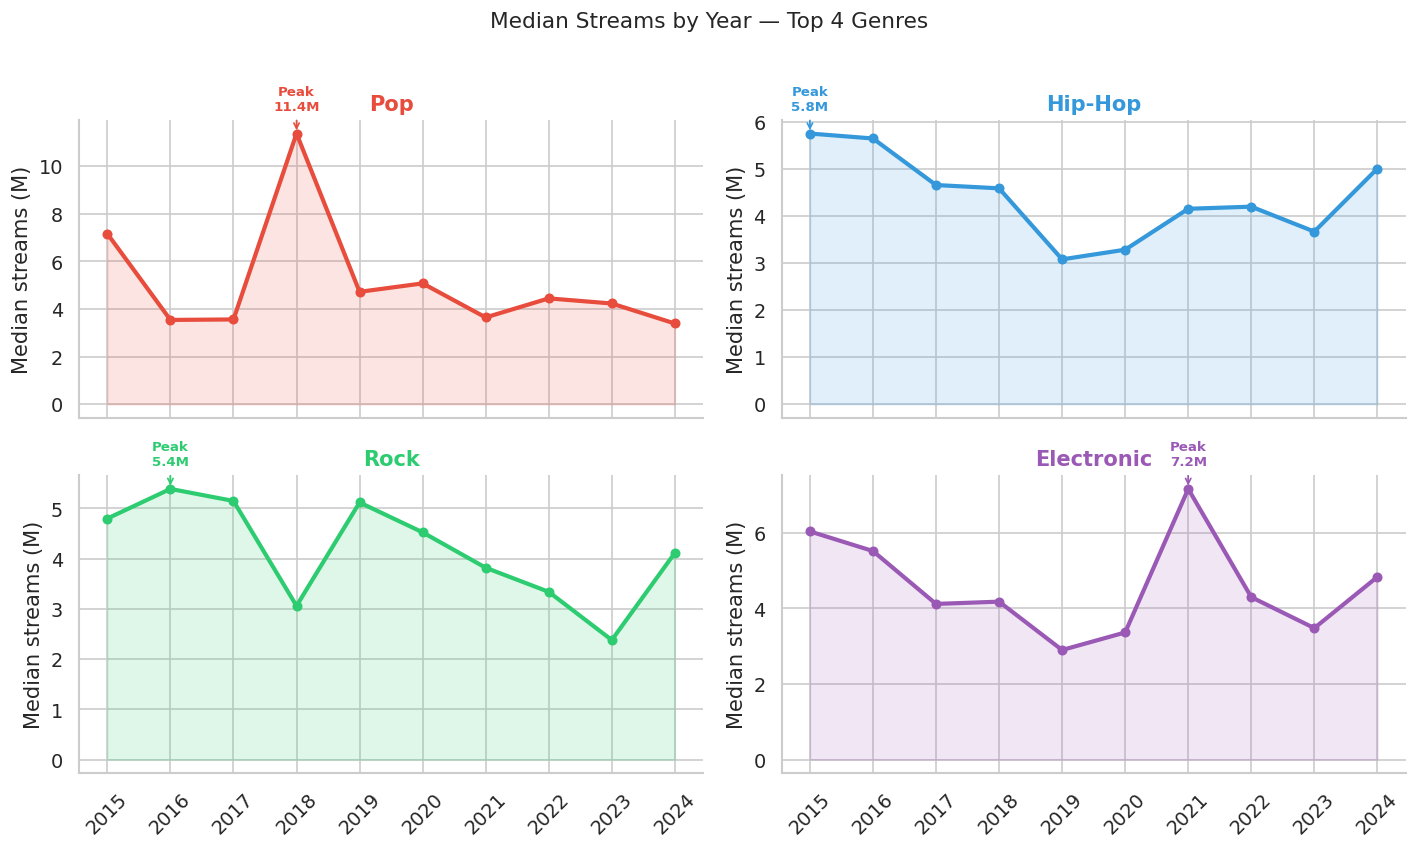

In [9]:
focus_genres = ['Pop', 'Hip-Hop', 'Rock', 'Electronic']
palette = {'Pop': '#e74c3c', 'Hip-Hop': '#3498db', 'Rock': '#2ecc71', 'Electronic': '#9b59b6'}

trend = (df[df.genre.isin(focus_genres)]
         .groupby(['year', 'genre'])['streams_millions']
         .median().reset_index())

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.flatten()

for ax, genre in zip(axes, focus_genres):
    g = trend[trend.genre == genre]
    color = palette[genre]

    ax.fill_between(g.year, g.streams_millions, alpha=0.15, color=color)
    ax.plot(g.year, g.streams_millions, color=color, lw=2.5, marker='o', ms=5)

    # Annotate peak
    peak_row = g.loc[g.streams_millions.idxmax()]
    ax.annotate(
        f"Peak\n{peak_row.streams_millions:.1f}M",
        xy=(peak_row.year, peak_row.streams_millions),
        xytext=(0, 14), textcoords='offset points',
        ha='center', fontsize=8, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color, lw=1)
    )

    ax.set_title(genre, fontweight='bold', color=color)
    ax.set_ylabel('Median streams (M)')
    ax.set_xticks(range(2015, 2025))
    ax.tick_params(axis='x', rotation=45)
    sns.despine(ax=ax)

fig.suptitle('Median Streams by Year — Top 4 Genres', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# Part 3 — Altair

## Interactive Histogram
### Click a genre in the legend to filter the stream distribution

In [10]:
sel = alt.selection_point(fields=['genre'], bind='legend')

alt.Chart(df[df.streams_millions < 150]).mark_bar(opacity=0.7).encode(
    x=alt.X('streams_millions:Q', bin=alt.Bin(maxbins=45), title='Streams (M)'),
    y=alt.Y('count():Q', title='Songs'),
    color=alt.Color('genre:N', scale=alt.Scale(scheme='tableau10'), title='Genre'),
    opacity=alt.condition(sel, alt.value(0.85), alt.value(0.08)),
    tooltip=['genre:N', 'count():Q',
             alt.Tooltip('streams_millions:Q', bin=alt.Bin(maxbins=45), title='Streams range (M)')]
).add_params(sel).properties(width=600, height=300)

alt.Chart(...)

## Interactive Scatter with Tooltip
### Energy vs valence — hover for track details, brush to select a region

In [11]:
brush = alt.selection_interval()
sample400 = df.sample(500, random_state=3).reset_index(drop=True)

scatter = alt.Chart(sample400).mark_circle(size=55).encode(
    x=alt.X('energy:Q', scale=alt.Scale(domain=[0,1])),
    y=alt.Y('valence:Q', scale=alt.Scale(domain=[0,1])),
    color=alt.condition(
        brush,
        alt.Color('genre:N', scale=alt.Scale(scheme='tableau10'), title='Genre'),
        alt.value('lightgray')
    ),
    size=alt.Size('streams_millions:Q', scale=alt.Scale(range=[20, 300]),
                  title='Streams (M)', legend=None),
    opacity=alt.condition(brush, alt.value(0.75), alt.value(0.15)),
    tooltip=[
        alt.Tooltip('title:N', title='Track'),
        alt.Tooltip('artist:N', title='Artist'),
        alt.Tooltip('genre:N', title='Genre'),
        alt.Tooltip('energy:Q', format='.2f'),
        alt.Tooltip('valence:Q', format='.2f'),
        alt.Tooltip('streams_millions:Q', title='Streams (M)', format='.1f'),
    ]
).add_params(brush).properties(width=580, height=380,
    title='Energy vs Valence — drag to select a region')

# Bar chart that reacts to brush
bars = alt.Chart(sample400).mark_bar().encode(
    x=alt.X('count():Q', title='Songs in selection'),
    y=alt.Y('genre:N', sort='-x', title=''),
    color=alt.Color('genre:N', scale=alt.Scale(scheme='tableau10'), legend=None)
).transform_filter(brush).properties(width=580, height=180, title='Genre breakdown of selection')

scatter & bars

alt.VConcatChart(...)